In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
df = pd.read_csv("student_scores.csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [3]:
df.tail()

,Hours,Scores
20,2.7,30
21,4.8,54
22,3.8,35
23,6.9,76
24,7.8,86


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [6]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [9]:
x = df["Hours"]
y = df["Scores"]

In [7]:
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)


In [12]:
x_train.shape

(20,)

In [13]:
y_train.shape

(20,)

In [14]:
x_test

8     8.3
16    2.5
0     2.5
23    6.9
11    5.9
Name: Hours, dtype: float64

In [15]:
x_train

9     2.7
13    3.3
1     5.1
22    3.8
5     1.5
2     3.2
12    4.5
15    8.9
3     8.5
4     3.5
20    2.7
17    1.9
21    4.8
18    6.1
24    7.8
7     5.5
10    7.7
14    1.1
19    7.4
6     9.2
Name: Hours, dtype: float64

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train.values.reshape(-1, 1), y_train.values.reshape(-1, 1))

beta_0 = model.intercept_[0]

beta_1 = model.coef_[0][0]

print("Estimated Model intercept, B0 : ", "{:.2f}".format(beta_0))
print("Estimated Model Coeffecients, B1 : ", beta_1)

Estimated Model intercept, B0 :  2.83
Estimated Model Coeffecients, B1 :  9.682078154455697


In [20]:
y_predict_train = model.predict(x_train.values.reshape(-1, 1))
y_predict_test = model.predict(x_test.values.reshape(-1, 1))


In [21]:
y_predict_train

array([[28.96850337],
       [34.77775026],
       [52.20549094],
       [39.61878934],
       [17.35000959],
       [33.80954245],
       [46.39624405],
       [88.99738793],
       [85.12455667],
       [36.71416589],
       [28.96850337],
       [21.22284085],
       [49.3008675 ],
       [61.8875691 ],
       [78.34710196],
       [56.0783222 ],
       [77.37889414],
       [13.47717832],
       [74.4742707 ],
       [91.90201137]])

In [22]:
y_predict_test

array([[83.18814104],
       [27.03208774],
       [27.03208774],
       [69.63323162],
       [59.95115347]])

Text(0.5, 1.0, 'SLR model of testing case')

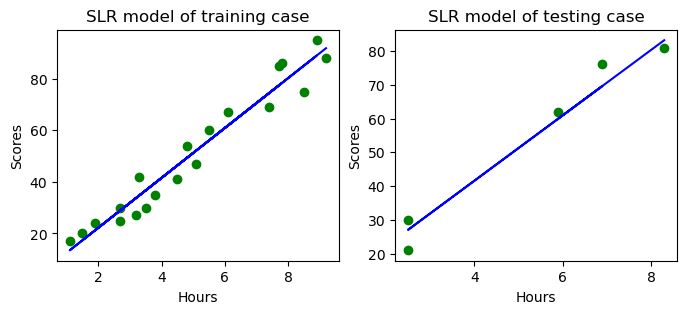

In [23]:
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(x_train, y_predict_train, color = 'blue', label = "Regression Line")
plt.scatter(x_train, y_train, c="green", label = "actual Values")
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("SLR model of training case")

plt.subplot(122)
plt.plot(x_test, y_predict_test, color = 'blue', label = "Regression Line")
plt.scatter(x_test, y_test, c="green", label = "actual Values")
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("SLR model of testing case")



In [26]:
error_test = pd.DataFrame(
    {
        'Actual Values':y_test.squeeze(),
        'Predicted Values' : y_predict_test.squeeze()
    }
)

error_test

,Actual Values,Predicted Values
8,81,83.188141
16,30,27.032088
0,21,27.032088
23,76,69.633232
11,62,59.951153


In [27]:
mse_train = mean_squared_error(y_train, y_predict_train)
mae_train = mean_absolute_error(y_train, y_predict_train)
r2_score_train = r2_score(y_train, y_predict_train)

print("The MSE for training is : ",mse_train)
print("The MAE for training is : ",mae_train)
print("The R2 Score for training is : ",r2_score_train)

The MSE for training is :  31.454835527366846
The MAE for training is :  5.221357478352559
The R2 Score for training is :  0.9491209376364416
